# Mall Customer Segmentation via K-Means

**Name:** Nuha c
**MUID:** nuha-2@mulearn

This notebook groups mall customers into distinct segments based on **Age, Gender, Annual Income, and Spending Score**, using K-Means clustering. The segments are then profiled and translated into concrete marketing strategies.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (8, 5)

## 1. Load & Explore the Data

In [2]:
df = pd.read_csv("Mall_Customers.csv")
df.head()

   CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male   49                  68                      86
1           2  Female   56                  22                      57
2           3    Male   66                  41                      29
3           4    Male   69                  41                      78
4           5    Male   49                 112                      92

In [3]:
df.shape

(200, 5)

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   CustomerID              200 non-null    int64
 1   Gender                  200 non-null    str  
 2   Age                     200 non-null    int64
 3   Annual Income (k$)      200 non-null    int64
 4   Spending Score (1-100)  200 non-null    int64
dtypes: int64(4), str(1)
memory usage: 7.9 KB


In [5]:
df.describe()

       CustomerID         Age  Annual Income (k$)  Spending Score (1-100)
count  200.000000  200.000000          200.000000              200.000000
mean   100.500000   44.405000           77.035000               49.800000
std     57.879185   15.353816           36.558397               29.454846
min      1.000000   18.000000           15.000000                1.000000
25%     50.750000   32.750000           44.000000               23.750000
50%    100.500000   46.000000           74.000000               48.500000
75%    150.250000   56.000000          111.000000               75.250000
max    200.000000   69.000000          139.000000               99.000000

In [6]:
df.isnull().sum()

CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0

No missing values are present in the dataset, so no imputation is required.

## 2. Data Preparation

* Drop `CustomerID` — it's an arbitrary identifier with no predictive value.
* Encode the categorical `Gender` column to binary (0 = Male, 1 = Female).
* No missing values were found, so no imputation is needed.

In [7]:
df_clean = df.drop(columns=['CustomerID']).copy()
df_clean['Gender'] = df_clean['Gender'].map({'Male': 0, 'Female': 1})
df_clean.head()

   Gender  Age  Annual Income (k$)  Spending Score (1-100)
0       0   49                  68                      86
1       1   56                  22                      57
2       0   66                  41                      29
3       0   69                  41                      78
4       0   49                 112                      92

## 3. Feature Scaling

K-Means relies entirely on **Euclidean distance**. Annual Income (roughly 15-140) and Age (18-70) live on very different scales than Spending Score (1-100) and the binary Gender column. Without scaling, Income would dominate the distance calculation and effectively drown out the other features. `StandardScaler` transforms every feature to zero mean and unit variance, giving each one equal weight in the clustering.

In [8]:
X = df_clean[['Gender', 'Age', 'Annual Income (k$)', 'Spending Score (1-100)']]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled[:5]

[[-1.     0.3   -0.248  1.232]
 [ 1.     0.757 -1.509  0.245]
 [-1.     1.41  -0.988 -0.708]
 [-1.     1.606 -0.988  0.96 ]
 [-1.     0.3    0.959  1.436]]

## 4. Finding the Optimal K — Elbow Method

We fit K-Means for k = 1 through 10 and plot the Within-Cluster Sum of Squares (WCSS / inertia) against k. The "elbow" — the point where adding more clusters stops giving a meaningful reduction in WCSS — indicates a good choice of k.

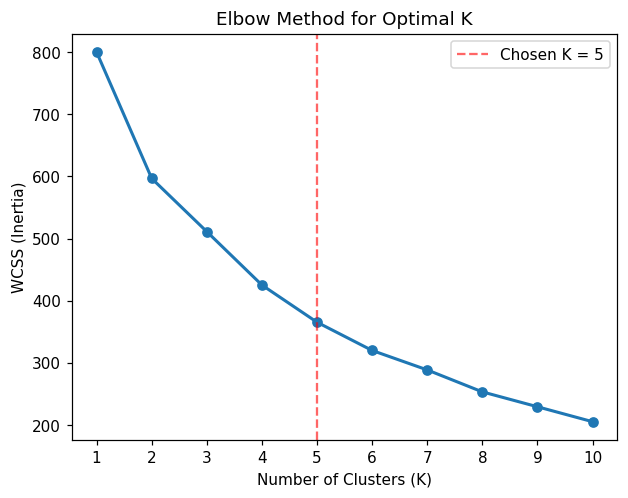

In [9]:
wcss = []
for k in range(1, 11):
    km = KMeans(n_clusters=k, init='k-means++', random_state=42, n_init=10)
    km.fit(X_scaled)
    wcss.append(km.inertia_)

plt.plot(range(1, 11), wcss, marker='o', linewidth=2)
plt.title('Elbow Method for Optimal K')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('WCSS (Inertia)')
plt.xticks(range(1, 11))
plt.axvline(x=5, color='red', linestyle='--', alpha=0.6, label='Chosen K = 5')
plt.legend()
plt.show()

The WCSS values are: `[800.0, 596.8, 511.2, 425.3, 365.5, 320.1, 288.7, 253.4, 229.5, 205.5]`.

The rate of decrease slows down noticeably after **K = 5** (the drop from K=5→6 and beyond becomes much smaller than the drops before it), so **K = 5** is chosen as the optimal number of clusters — consistent with the assignment's target of 5 segments.

## 5. Train the K-Means Model

In [10]:
kmeans = KMeans(n_clusters=5, init='k-means++', random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(X_scaled)
df_clean['Cluster'] = cluster_labels

sil_score = silhouette_score(X_scaled, cluster_labels)
print(f"Silhouette Score: {sil_score:.3f}")
df_clean['Cluster'].value_counts().sort_index()

Silhouette Score: 0.267


Cluster
0    37
1    42
2    46
3    44
4    31

## 6. Cluster Profiling

In [11]:
profile = df_clean.groupby('Cluster').agg(
    Count=('Cluster', 'count'),
    Pct_Female=('Gender', lambda x: round(x.mean()*100, 1)),
    Avg_Age=('Age', lambda x: round(x.mean(), 1)),
    Avg_Income=('Annual Income (k$)', lambda x: round(x.mean(), 1)),
    Avg_Spending=('Spending Score (1-100)', lambda x: round(x.mean(), 1)),
)
profile

         Count  Pct_Female  Avg_Age  Avg_Income  Avg_Spending
Cluster                                                      
0           37        73.0     27.4        62.8          78.7
1           42       100.0     55.0        48.4          44.2
2           46         0.0     56.7        74.1          61.2
3           44         0.0     33.8        93.8          28.2
4           31       100.0     47.1       113.5          36.6

Based on these profiles, we can name the five segments:

| Cluster | Segment Name | Profile |
|---|---|---|
| 0 | **Young High Spenders** | Mostly female (73%), avg age 27, mid income ($63k), very high spending score (79) |
| 1 | **Middle-Aged Moderate Women** | 100% female, avg age 55, mid income ($48k), moderate spending (44) |
| 2 | **Older Affluent Active Men** | 100% male, avg age 57, high income ($74k), solid spending (61) |
| 3 | **High-Earning Cautious Men** | 100% male, avg age 34, highest-mid income ($94k), very low spending (28) |
| 4 | **High-Earning Reserved Women** | 100% female, avg age 47, highest income ($114k), low-moderate spending (37) |

## 7. Dimensionality Reduction with PCA

The clustering used 4 features, which can't be visualized directly. We use **Principal Component Analysis (PCA)** to project the scaled data down to 2 principal components so the segments can be plotted on a 2D scatter plot.

In [12]:
pca = PCA(n_components=2, random_state=42)
pcs = pca.fit_transform(X_scaled)
df_clean['PC1'] = pcs[:, 0]
df_clean['PC2'] = pcs[:, 1]

print("Explained variance ratio:", pca.explained_variance_ratio_)
print(f"Total variance captured by 2 components: {pca.explained_variance_ratio_.sum()*100:.2f}%")

Explained variance ratio: [0.2921 0.2559]
Total variance captured by 2 components: 54.80%


The two principal components together capture **54.80%** of the total variance in the scaled feature space.

## 8. Visualize the Segments

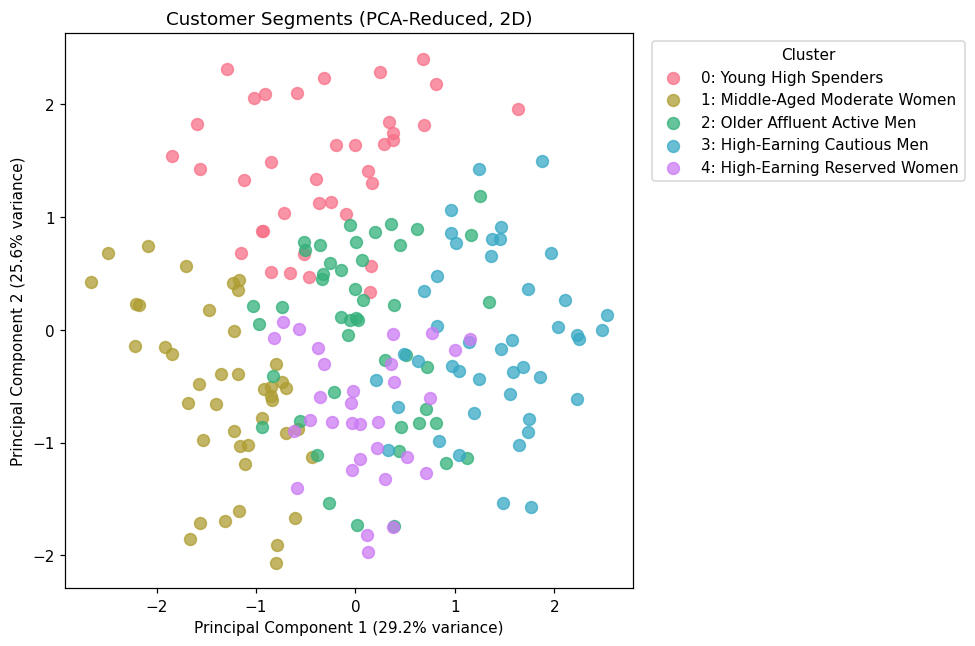

In [13]:
segment_names = {
    0: "Young High Spenders",
    1: "Middle-Aged Moderate Women",
    2: "Older Affluent Active Men",
    3: "High-Earning Cautious Men",
    4: "High-Earning Reserved Women",
}

plt.figure(figsize=(9, 6))
palette = sns.color_palette("husl", 5)
for c in sorted(df_clean['Cluster'].unique()):
    subset = df_clean[df_clean['Cluster'] == c]
    plt.scatter(subset['PC1'], subset['PC2'], s=60, alpha=0.75,
                color=palette[c], label=f"{c}: {segment_names[c]}")

plt.title('Customer Segments (PCA-Reduced, 2D)')
plt.xlabel(f'Principal Component 1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)')
plt.ylabel(f'Principal Component 2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)')
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', title="Cluster")
plt.tight_layout()
plt.show()

For an intuitive sanity check, here are the same clusters plotted on the raw **Annual Income vs Spending Score** axes (the two features that separate customers most clearly):

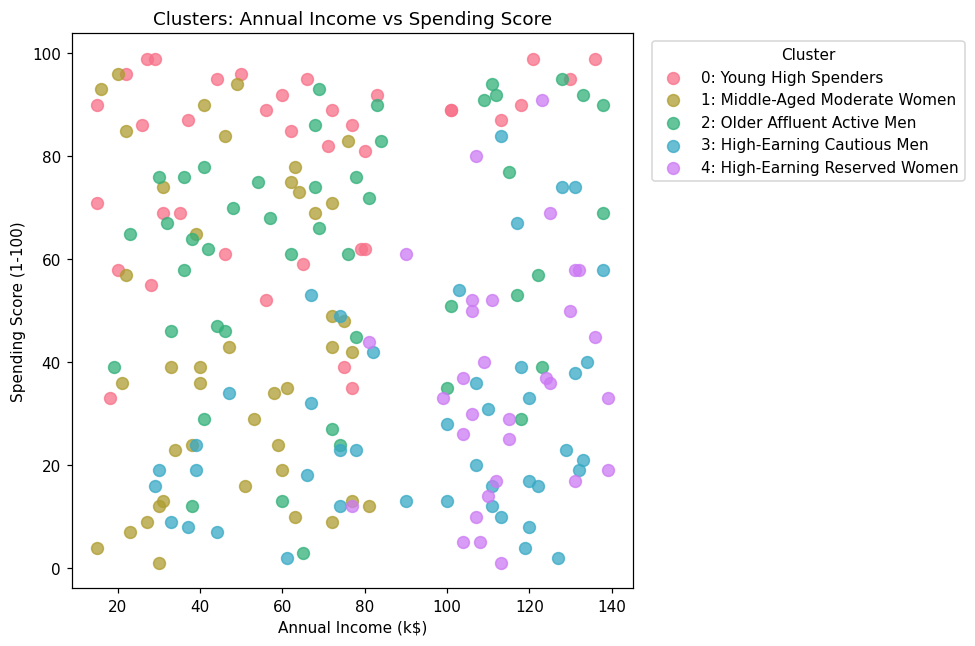

In [14]:
plt.figure(figsize=(9, 6))
for c in sorted(df_clean['Cluster'].unique()):
    subset = df_clean[df_clean['Cluster'] == c]
    plt.scatter(subset['Annual Income (k$)'], subset['Spending Score (1-100)'],
                s=60, alpha=0.75, color=palette[c], label=f"{c}: {segment_names[c]}")
plt.title('Clusters: Annual Income vs Spending Score')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', title="Cluster")
plt.tight_layout()
plt.show()

## 9. Insights & Business Strategies

**Key observations**
- Gender turned out to be a strong separator once Age and Income were included: three of the five clusters are single-gender, driven by how income and spending combine differently across men and women in this dataset.
- The biggest spenders relative to income are the **Young High Spenders** (Cluster 0) — a mid-income, high-spending, younger crowd.
- The two "high income, low spending" segments (**Cluster 3** and **Cluster 4**) represent the greatest untapped revenue opportunity — they can afford to spend more than they currently do.
- **Cluster 2**, older affluent men, already spend at a healthy rate and are a stable, reliable revenue base.

**Recommended strategies**

| Segment | Strategy |
|---|---|
| **Cluster 0 – Young High Spenders** | Retain with loyalty programs, trend-driven collections, and early access drops — they're already highly engaged. |
| **Cluster 1 – Middle-Aged Moderate Women** | Grow wallet share with targeted bundle offers and seasonal promotions matched to mid-range budgets. |
| **Cluster 2 – Older Affluent Active Men** | Maintain relationship with premium loyalty perks and personalized service; a dependable revenue segment. |
| **Cluster 3 – High-Earning Cautious Men** | Highest-priority growth target: use premium/exclusive product positioning, high-touch personal shopping, or invite-only events to convert income into spend. |
| **Cluster 4 – High-Earning Reserved Women** | Similar to Cluster 3 — luxury or investment-piece marketing, VIP previews, and personalized outreach to unlock latent spending power. |